## Сравнение Decision Tree и XGBoost на задаче классификации сетевого трафика IoT

**Гипотеза:** На хорошо разделимых данных (IoT-трафик N-BaIoT) простое дерево решений показывает сопоставимую точность с XGBoost, тогда как бустинг требует кратно больше вычислительного времени - что ставит под сомнение его целесообразность в подобных условиях.

---
## 1. Выбор датасета

### 1.1 Источник данных

**Датасет:** [N-BaIoT - Network-based detection of IoT Botnet attacks](https://www.kaggle.com/datasets/mkashifn/nbaiot-dataset)  
**Формат:** CSV (набор файлов, разбитых по устройствам и типам трафика)

Датасет собран в лабораторных условиях: исследователи заразили реальные IoT-устройства (IP-камеры, роутеры) вредоносным ПО семейств **Mirai** и **BASHLITE**, после чего отслеживали сетевой трафик. Каждая строка - это набор характеристик TCP/UDP-потоков (длина пакетов, скорость, энтропия и тд), вычисленных за определённое временное окно.

### 1.2 Структура файлов

Файлы имеют формат `<device_id>.<тип_трафика>.csv`:

| Шаблон имени файла | Тип трафика |
|---|---|
| `*.benign.csv` | Нормальный трафик |
| `*.mirai.ack.csv` | ACK-флуд (Mirai) |
| `*.mirai.scan.csv` | Сканирование портов (Mirai) |
| `*.mirai.syn.csv` | SYN-флуд (Mirai) |
| `*.mirai.udp.csv` | UDP-флуд (Mirai) |
| `*.mirai.udpplain.csv` | UDP Plain флуд (Mirai) |
| `*.gafgyt.combo.csv` | Комбинированная атака (BASHLITE) |
| `*.gafgyt.junk.csv` | Junk-флуд (BASHLITE) |
| `*.gafgyt.scan.csv` | Сканирование (BASHLITE) |
| `*.gafgyt.tcp.csv` | TCP-флуд (BASHLITE) |
| `*.gafgyt.udp.csv` | UDP-флуд (BASHLITE) |

### 1.3 Релевантность для задачи

Датасет подходит для двух задач классификации:
- **Бинарная:** `benign vs. attack` - нормальный трафик или атака?
- **Мультиклассовая:** определить конкретный тип атаки (11 классов)

In [1]:
import os
import gc
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

SEED = 42

In [2]:
DATASET_ROOT = './data'

def parse_filename(filepath):
    """Парсит имя файла вида '1.gafgyt.combo.csv' -> (device_id, botnet, attack, label)."""
    parts = os.path.basename(filepath).replace('.csv', '').split('.')
    dev = int(parts[0])
    if parts[1] == 'benign':
        return dev, 'benign', 'benign', 'benign'
    return dev, parts[1], parts[2], f"{parts[1]}.{parts[2]}"

csv_files = sorted([f for f in glob.glob(os.path.join(DATASET_ROOT, '[0-9]*.csv'))
                     if 'Zone' not in f])

records = []
for fpath in csv_files:
    dev, botnet, attack, label = parse_filename(fpath)
    tmp = pd.read_csv(fpath, dtype=np.float32)
    tmp['label'] = label
    tmp['binary_label'] = np.int8(0 if botnet == 'benign' else 1)
    records.append(tmp)

df = pd.concat(records, ignore_index=True)
del records; gc.collect()

df['label'] = df['label'].astype('category')

print(f'Датасет загружен: {df.shape[0]:,} строк, {df.shape[1]} столбцов')
print(f'Память: {df.memory_usage(deep=True).sum() / 1024**3:.2f} ГБ')

Датасет загружен: 7,062,606 строк, 117 столбцов
Память: 3.04 ГБ


### 1.4 Размерность датасета

In [ ]:
n_rows, n_cols = df.shape
n_features = n_cols - 2

print(f'Строк: {n_rows:>23,}')
print(f'Признаков: {n_features:>15}')
print(f'Классов (мульти): {df["label"].nunique():>6}')
print(f'Классов (бинарно): {df["binary_label"].nunique():>5}')
print(f'\nФормат данных: CSV, все признаки числовые (float32)')
print(f'Типы данных:')
print(df.dtypes.value_counts())

Строк:               7,062,606
Признаков:             115
Классов (мульти):     11
Классов (бинарно):     2

Формат данных: CSV, все признаки числовые (float32)
Типы данных:
float32     115
category      1
int8          1
Name: count, dtype: int64


---
## 2. Предварительный анализ данных (EDA)

### 2.1 Основные статистики

In [4]:
feature_cols = [c for c in df.columns if c not in ('label', 'binary_label')]

sample_for_stats = df.sample(min(500_000, len(df)), random_state=SEED)
stats = sample_for_stats[feature_cols].describe().T
stats['median'] = sample_for_stats[feature_cols].median()
stats = stats[['count', 'mean', 'median', 'std', 'min', 'max']]
stats.columns = ['Count', 'Mean', 'Median', 'Std', 'Min', 'Max']
del sample_for_stats; gc.collect()

print('Статистики по первым 10 признакам (на выборке 500K):')
stats.head(10)

Статистики по первым 10 признакам (на выборке 500K):


,Count,Mean,Median,Std,Min,Max
MI_dir_L5_weight,500000.0000,81.8245,91.7684,68.9577,1.0000,428.0708
MI_dir_L5_mean,500000.0000,178.8326,74.0100,165.2736,60.0000,1452.6749
MI_dir_L5_variance,500000.0000,15477.3555,5.7644,24047.1465,0.0000,475648.1562
MI_dir_L3_weight,500000.0000,129.4714,141.3361,109.4153,1.0000,551.6883
MI_dir_L3_mean,500000.0000,178.9461,74.0217,160.1221,60.0000,1450.6953
MI_dir_L3_variance,500000.0000,17163.5391,14.7748,25129.1680,0.0000,471456.8125
MI_dir_L1_weight,500000.0000,367.7596,383.7040,312.8191,1.0000,1205.3123
MI_dir_L1_mean,500000.0000,179.2513,74.0423,155.6993,60.0000,1432.8524
MI_dir_L1_variance,500000.0000,18607.3027,37.4529,26046.7031,0.0000,471261.9062
MI_dir_L0.1_weight,500000.0000,3407.1267,3661.3428,2898.0720,1.0000,8946.9971


In [5]:
print('Сводка по диапазонам значений:')
print(f'Признаков с Max > 1e6: {(stats["Max"] > 1e6).sum()}')
print(f'Признаков с нулевым Std: {(stats["Std"] == 0).sum()} (постоянные - кандидаты на удаление)')
print(f'Признаков с Min < 0: {(stats["Min"] < 0).sum()}')

Сводка по диапазонам значений:
Признаков с Max > 1e6: 10
Признаков с нулевым Std: 0 (постоянные - кандидаты на удаление)
Признаков с Min < 0: 20


### 2.2 Распределение целевой переменной

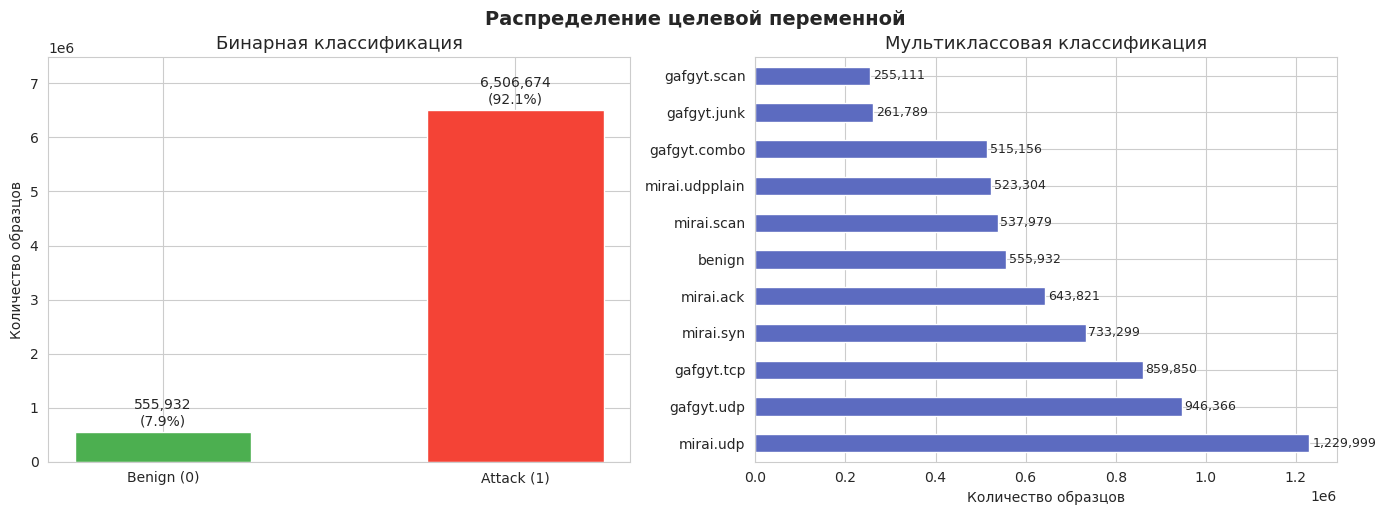

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Бинарная
bin_counts = df['binary_label'].value_counts().sort_index()
labels_bin = ['Benign (0)', 'Attack (1)']
colors_bin = ['#4CAF50', '#F44336']
axes[0].bar(labels_bin, bin_counts.values, color=colors_bin, edgecolor='white', width=0.5)
for i, v in enumerate(bin_counts.values):
    axes[0].text(i, v + max(bin_counts.values)*0.01, f'{v:,}\n({v/len(df)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=10)
axes[0].set_title('Бинарная классификация', fontsize=13)
axes[0].set_ylabel('Количество образцов')
axes[0].set_ylim(0, max(bin_counts.values) * 1.15)

# Мультиклассовая
multi_counts = df['label'].value_counts()
multi_counts.plot(kind='barh', ax=axes[1], color='#5C6BC0', edgecolor='white')
axes[1].set_title('Мультиклассовая классификация', fontsize=13)
axes[1].set_xlabel('Количество образцов')
axes[1].set_ylabel('')
for i, v in enumerate(multi_counts.values):
    axes[1].text(v + max(multi_counts.values)*0.005, i, f'{v:,}', va='center', fontsize=9)

plt.tight_layout()
plt.suptitle('Распределение целевой переменной', fontsize=14, y=1.02, fontweight='bold')
plt.show()

### 2.3 Визуализация ключевых признаков

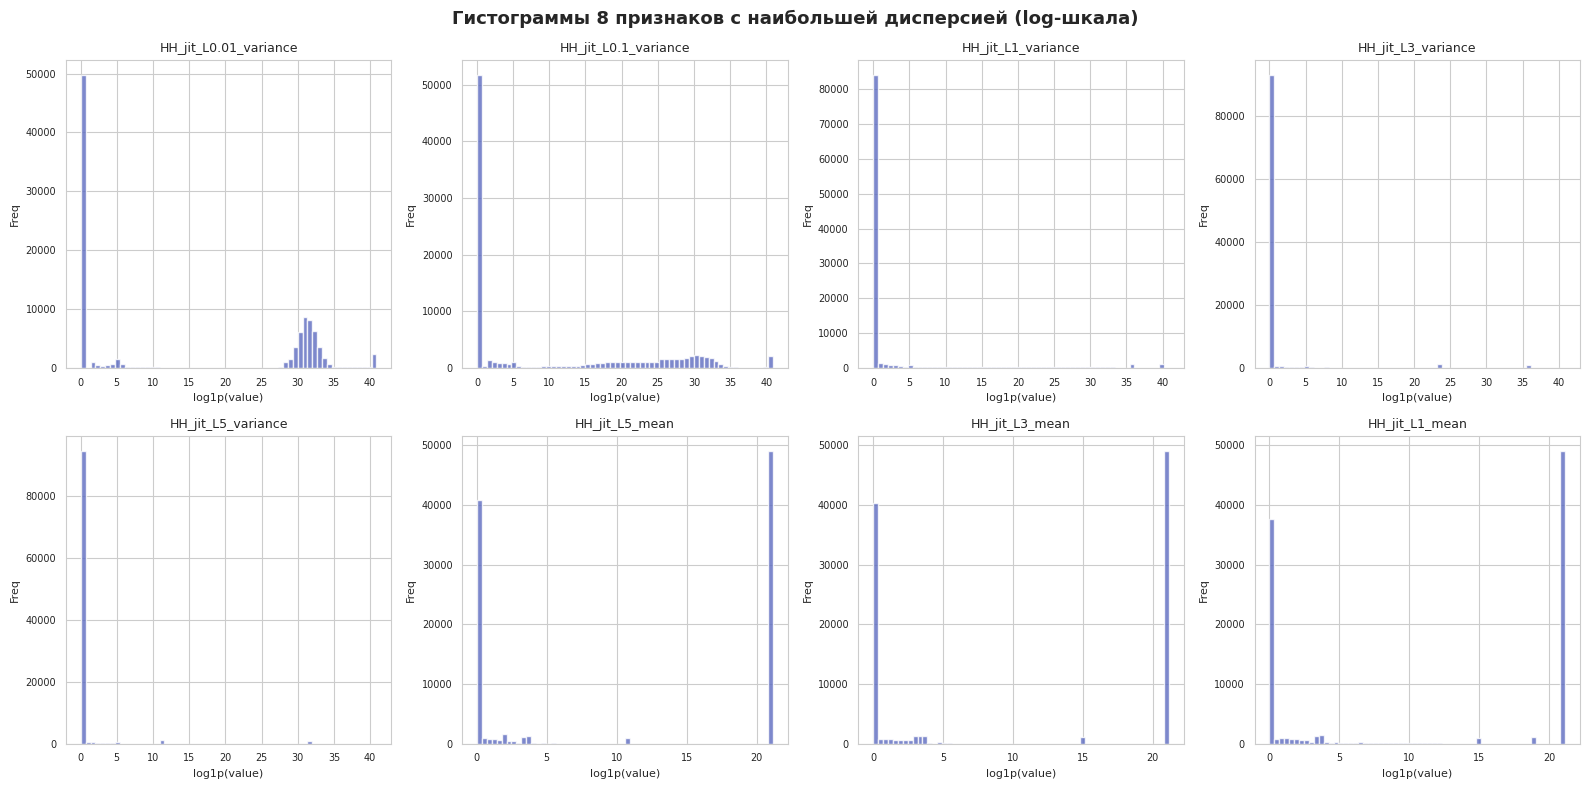

6961

In [7]:
sample_vis = df.sample(min(100_000, len(df)), random_state=SEED)
top_features = sample_vis[feature_cols].std().nlargest(8).index.tolist()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    vals = np.log1p(sample_vis[feat].clip(lower=0))
    axes[i].hist(vals, bins=60, color='#5C6BC0', alpha=0.8, edgecolor='white')
    axes[i].set_title(feat[:30], fontsize=9)
    axes[i].set_xlabel('log1p(value)', fontsize=8)
    axes[i].set_ylabel('Freq', fontsize=8)
    axes[i].tick_params(labelsize=7)

plt.suptitle('Гистограммы 8 признаков с наибольшей дисперсией (log-шкала)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
del sample_vis; gc.collect()

### 2.4 Выявление проблем в данных

In [8]:
n_missing = 0
for col in feature_cols:
    n_missing += df[col].isnull().sum()

print('Пропущенные значения:')
if n_missing == 0:
    print('Пропущенных значений не обнаружено')
else:
    print(f'Всего пропусков: {n_missing}')

Пропущенные значения:
Пропущенных значений не обнаружено


In [9]:
print('Оценка выбросов (IQR-метод, на выборке 200K)')

sample_out = df.sample(min(200_000, len(df)), random_state=SEED)
outlier_counts = {}
for feat in feature_cols:
    Q1 = sample_out[feat].quantile(0.25)
    Q3 = sample_out[feat].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((sample_out[feat] < Q1 - 1.5 * IQR) | (sample_out[feat] > Q3 + 1.5 * IQR)).sum()
    outlier_counts[feat] = n_out
del sample_out; gc.collect()

out_series = pd.Series(outlier_counts).sort_values(ascending=False)
print(f'Признаков с выбросами (>0): {(out_series > 0).sum()} из {len(feature_cols)}')
print('\nТоп-10 признаков по количеству выбросов:')
print(out_series.head(10).to_string())

print('\nВ сетевом трафике выбросы часто несут значимую информацию — не удаляем')

Оценка выбросов (IQR-метод, на выборке 200K)
Признаков с выбросами (>0): 96 из 115

Топ-10 признаков по количеству выбросов:
HH_L3_radius           48626
HH_L0.1_magnitude      48188
HH_L3_magnitude        48108
HH_L1_magnitude        48103
HH_L5_magnitude        48100
HH_L0.01_magnitude     47979
HH_L0.1_mean           47941
HH_L5_mean             47714
HpHp_L0.1_magnitude    47705
HpHp_L5_mean           47700

В сетевом трафике выбросы часто несут значимую информацию — не удаляем


In [10]:
print('Дисбаланс классов (бинарная задача)')
bin_dist = df['binary_label'].value_counts(normalize=True) * 100
print(f'Benign (0): {bin_dist.get(0, 0):.1f}%')
print(f'Attack (1): {bin_dist.get(1, 0):.1f}%')

ratio = bin_dist.max() / bin_dist.min() if bin_dist.min() > 0 else float('inf')
print(f'Соотношение мажоритарный:миноритарный = {ratio:.1f}:1')

if ratio > 5:
    print('Значительный дисбаланс, нужна балансировка')
elif ratio > 2:
    print('Умеренный дисбаланс, балансировка на усмотрение')
else:
    print('Классы сбалансированы, специальных мер не требуется')

print('\nДисбаланс классов (мультиклассовая задача)')
mc_dist = df['label'].value_counts(normalize=True) * 100
print(mc_dist.round(2).to_string())

Дисбаланс классов (бинарная задача)
Benign (0): 7.9%
Attack (1): 92.1%
Соотношение мажоритарный:миноритарный = 11.7:1
Значительный дисбаланс, нужна балансировка

Дисбаланс классов (мультиклассовая задача)
label
mirai.udp        17.4200
gafgyt.udp       13.4000
gafgyt.tcp       12.1700
mirai.syn        10.3800
mirai.ack         9.1200
benign            7.8700
mirai.scan        7.6200
mirai.udpplain    7.4100
gafgyt.combo      7.2900
gafgyt.junk       3.7100
gafgyt.scan       3.6100


### 2.5 Корреляция признаков с целевой переменной

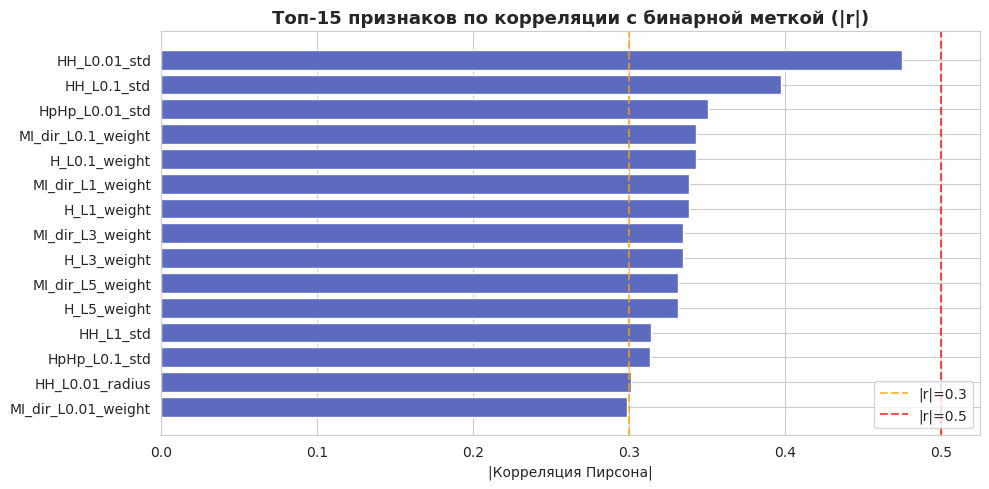

Признаков с |r| > 0.5: 0
Признаков с |r| > 0.3: 14


In [11]:
sample_corr = df.sample(min(200_000, len(df)), random_state=SEED)
corr_with_target = sample_corr[feature_cols].corrwith(sample_corr['binary_label']).abs().sort_values(ascending=False)
del sample_corr; gc.collect()

fig, ax = plt.subplots(figsize=(10, 5))
top_corr = corr_with_target.head(15)
ax.barh(top_corr.index[::-1], top_corr.values[::-1], color='#5C6BC0', edgecolor='white')
ax.set_title('Топ-15 признаков по корреляции с бинарной меткой (|r|)', fontsize=13, fontweight='bold')
ax.set_xlabel('|Корреляция Пирсона|')
ax.axvline(0.3, color='orange', linestyle='--', alpha=0.7, label='|r|=0.3')
ax.axvline(0.5, color='red', linestyle='--', alpha=0.7, label='|r|=0.5')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Признаков с |r| > 0.5: {(corr_with_target > 0.5).sum()}')
print(f'Признаков с |r| > 0.3: {(corr_with_target > 0.3).sum()}')

## 3. Предобработка данных

### 3.1 Обработка пропущенных значений

По результатам анализа датасет не содержит пропущенных значений

### 3.2 Масштабирование данных

Деревья решений и XGBoost не требуют масштабирования для качества предсказания. Однако для корректной работы PCA (раздел 3.4) используется **StandardScaler** — он центрирует каждый признак (среднее = 0) и нормализует дисперсию (std = 1), чтобы компоненты PCA не были захвачены признаками с большим масштабом значений.

> **Почему не RobustScaler для PCA?** RobustScaler устойчив к выбросам, но не приводит дисперсию к единице. В результате признаки с огромным разбросом (max > 10⁶) доминируют в первых компонентах, и PCA показывает «1 компонента = 99% дисперсии» — артефакт масштаба, а не реальная низкая размерность.

In [12]:
from sklearn.preprocessing import RobustScaler, LabelEncoder

feature_cols_clean = [c for c in feature_cols if df[c].std() > 0]
removed = len(feature_cols) - len(feature_cols_clean)
print(f'Постоянных признаков (std=0): {removed}')
if removed > 0:
    print(f'Удалено: {set(feature_cols) - set(feature_cols_clean)}')
    feature_cols = feature_cols_clean

scaler = RobustScaler()
scaler.fit(df[feature_cols])

y_binary = df['binary_label'].values
y_multi = df['label'].values

le = LabelEncoder()
y_multi_enc = le.fit_transform(y_multi)

print(f'\nScaler обучен на {len(df):,} строк × {len(feature_cols)} признаков')
print(f'Классы (мультиклассовая задача):')
for i, cls in enumerate(le.classes_):
    print(f'  {i:2d} - {cls}')

Постоянных признаков (std=0): 0

Scaler обучен на 7,062,606 строк × 115 признаков
Классы (мультиклассовая задача):
   0 - benign
   1 - gafgyt.combo
   2 - gafgyt.junk
   3 - gafgyt.scan
   4 - gafgyt.tcp
   5 - gafgyt.udp
   6 - mirai.ack
   7 - mirai.scan
   8 - mirai.syn
   9 - mirai.udp
  10 - mirai.udpplain


### 3.3 Категориальные признаки

Категориальных признаков нет.

### 3.4 Снижение размерности

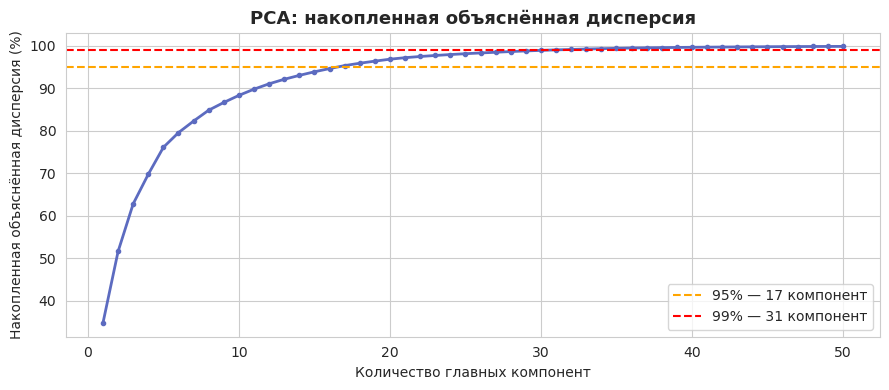

95% дисперсии — 17 компонент (из 115)
99% дисперсии — 31 компонент


In [13]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sample_pca = df.sample(min(100_000, len(df)), random_state=SEED)
pca_scaler = StandardScaler()
X_pca_sample = pca_scaler.fit_transform(sample_pca[feature_cols]).astype(np.float64)
del sample_pca

pca_exp = PCA(n_components=min(50, X_pca_sample.shape[1]), random_state=SEED)
pca_exp.fit(X_pca_sample)
del X_pca_sample; gc.collect()

cumvar = np.cumsum(pca_exp.explained_variance_ratio_)
n95 = np.argmax(cumvar >= 0.95) + 1
n99 = np.argmax(cumvar >= 0.99) + 1

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, len(cumvar)+1), cumvar * 100, marker='.', color='#5C6BC0', linewidth=2)
ax.axhline(95, color='orange', linestyle='--', label=f'95% — {n95} компонент')
ax.axhline(99, color='red', linestyle='--', label=f'99% — {n99} компонент')
ax.set_xlabel('Количество главных компонент')
ax.set_ylabel('Накопленная объяснённая дисперсия (%)')
ax.set_title('PCA: накопленная объяснённая дисперсия', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f'95% дисперсии — {n95} компонент (из {len(feature_cols)})')
print(f'99% дисперсии — {n99} компонент')

## 4. Выбор алгоритмов и метрик оценки

### 4.1 Обоснование выбора алгоритмов

#### Decision Tree (одиночное дерево решений)

- **Интерпретируемость:** легко визуализировать и объяснить, почему трафик классифицирован как атака
- **Скорость:** обучение и инференс на CPU существенно быстрее ансамблевых методов
- **Базовый алгоритм:** хорошая точка отсчёта для оценки того, что привносит бустинг

#### XGBoost (gradient boosting)

- **Итеративное исправление ошибок:** последовательно строит деревья, корректируя остатки предыдущих
- **Регуляризация:** встроенные L1/L2-штрафы снижают переобучение

#### Почему оба алгоритма запускаются на CPU

1. **Честность сравнения:** GPU-ускоренный XGBoost (CUDA) против CPU-дерева был бы некорректным сопоставлением
2. **Доступность:** не всегда есть возможность запуска на GPU
3. **Реалистичность:** обучение на GPU стоит дороже

### 4.2 Метрики оценки

| Метрика | Обоснование |
|---|---|
| **Accuracy** | Общая доля правильных ответов |
| **Precision** | Сколько из "атак" реально атаки (ложные тревоги) |
| **Recall** | Сколько реальных атак обнаружено (пропущенные угрозы) |
| **F1-score** | Баланс Precision/Recall |
| **Время обучения** | **Ключевая метрика для поставленной гипотезы** |

### 4.3 Борьба с переобучением

| Метод | Decision Tree | XGBoost |
|---|---|---|
| Ограничение глубины (`max_depth`) | + | + |
| Минимальное количество образцов в листе (`min_samples_leaf`) | + | + |
| L1/L2-регуляризация | - | + |
| Ранняя остановка | - | + |


---
## 5. Инструментарий для улучшения качества данных

### 5.1 Аугментация данных

Не требуется

### 5.2 Балансировка классов

In [14]:
bin_ratio = pd.Series(y_binary).value_counts(normalize=True)
imbalance_ratio = bin_ratio.max() / bin_ratio.min()

print(f'Соотношение классов (бинарная): {imbalance_ratio:.1f}:1')
print()

print('Способы борьбы с дисбалансом:')
print('class_weight="balanced" в DecisionTreeClassifier')
print('scale_pos_weight = N_negative / N_positive в XGBoost')

Соотношение классов (бинарная): 11.7:1

Способы борьбы с дисбалансом:
class_weight="balanced" в DecisionTreeClassifier
scale_pos_weight = N_negative / N_positive в XGBoost
